# Medicine Price Prediction — Online Pharmacy Finder

## Mission
This model supports an **online pharmacy finder** app: a service that helps
people locate medicines without physically visiting multiple pharmacies.
One of the biggest frictions in that journey is not knowing whether a price
quoted by a pharmacy is fair. This notebook builds a regression model that
predicts the **expected market price of a medicine** from its attributes
(manufacturer, pack size, composition strength, therapeutic class, etc.),
so the app can flag listings that are priced well above what's expected and
steer users toward better options — without needing to check pharmacy after
pharmacy in person.

## Dataset
Two public Kaggle datasets (India) are merged on medicine name:
- **A-Z Medicine Dataset of India** (~254k rows): `name`, `price`,
  `manufacturer_name`, `pack_size_label`, `short_composition1/2`,
  `Is_discontinued`.
- **250k Medicines Usage, Side Effects and Substitutes** (~248k rows):
  `substitutes`, `sideEffects`, `uses`, `Chemical Class`,
  `Therapeutic Class`, `Habit Forming`.

Merging gives both **volume** (~217k rows after cleaning) and **variety**
(numeric + categorical + text-derived features) well beyond a single flat
table.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
DATA_DIR = "data"   # place the two source CSVs here (see README)


## 2. Load & merge the two source datasets

We join on a normalized medicine name (`name_key`) since the two datasets use
different casing/spacing conventions. Duplicate name keys inside either
dataset are dropped first so the join doesn't multiply rows.

In [2]:
az = pd.read_csv(f"{DATA_DIR}/A_Z_medicines_dataset_of_India.csv")
md_df = pd.read_csv(f"{DATA_DIR}/medicine_dataset.csv", low_memory=False)
print("A-Z medicines dataset:", az.shape)
print("Usage/side-effects dataset:", md_df.shape)

az["name_key"] = az["name"].str.strip().str.lower()
md_df["name_key"] = md_df["name"].str.strip().str.lower()
az = az.drop_duplicates(subset="name_key", keep="first")
md_df = md_df.drop_duplicates(subset="name_key", keep="first")

df = az.merge(md_df.drop(columns=["name"]), on="name_key", how="inner")
print("Merged dataset:", df.shape)


A-Z medicines dataset: (253973, 9)
Usage/side-effects dataset: (248218, 58)
Merged dataset: (221415, 67)


## 3. Cleaning

- Rename `price(₹)` → `price`, drop non-positive/invalid prices.
- Drop `type`: every row is `"allopathy"` — a constant column carries no
  signal for the model, so it is removed.

In [3]:
df = df.rename(columns={"price(₹)": "price"})
df = df[df["price"] > 0].copy()
df = df.drop(columns=["type"])
print(df["price"].describe())


count    221411.000000
mean        278.136092
std        3049.028853
min           1.050000
25%          48.000000
50%          79.000000
75%         141.000000
max      396725.000000
Name: price, dtype: float64


## 4. Feature engineering

Interpretation drives every decision below:

| Feature | Why it's engineered this way |
|---|---|
| `manufacturer_size` | Frequency-encoded (# products listed) instead of one-hot (7,648 unique manufacturers would be unusable). Proxy for how large/established a manufacturer is. |
| `pack_container`, `pack_quantity`, `pack_form` | Parsed out of free text like `"strip of 10 tablets"` — bigger packs / different delivery forms (injection vs tablet) plausibly command different prices. |
| `composition1_strength_mg` | Parsed dosage strength (e.g. `"(500mg)"`) from the composition text — higher active-ingredient dose is a natural price driver. |
| `has_composition2` | Flags combination drugs (2 active ingredients), which are often priced differently from single-ingredient drugs. |
| `num_substitutes`, `num_side_effects`, `num_uses` | Counts derived from the wide substitute/side-effect/use columns in the second dataset — a proxy for how "common/generic" vs "specialized" a drug is. |
| `therapeutic_class` | Kept as one-hot (only 22 categories) — strong, interpretable signal (see EDA below: vaccines and anti-neoplastics cost far more than pain analgesics). |
| `chemical_class` | 872 raw categories bucketed to the top 20 + `"OTHER"` to keep the encoding tractable while retaining the most common, informative classes. |
| `Action Class` | **Dropped** — 431 categories with heavy overlap with Chemical/Therapeutic Class; keeping it would blow up dimensionality for little extra signal. |


In [4]:
df["is_discontinued"] = df["Is_discontinued"].astype(int)

manufacturer_freq = df["manufacturer_name"].value_counts()
df["manufacturer_size"] = df["manufacturer_name"].map(manufacturer_freq)

def parse_pack(label):
    label = str(label).lower()
    m = re.match(r"([a-z]+) of ([\d.]+)\s*(ml|gm|mg)?\s*(.*)", label)
    if m:
        container, qty, unit, form = m.groups()
        qty = float(qty)
        form = form.strip() if form else unit
        return container, qty, form
    return "other", np.nan, "other"

parsed = df["pack_size_label"].apply(parse_pack)
df["pack_container"] = parsed.apply(lambda x: x[0])
df["pack_quantity"] = parsed.apply(lambda x: x[1])
df["pack_form"] = parsed.apply(lambda x: x[2])

# bucket rare forms/containers into "other"
for col in ["pack_form", "pack_container"]:
    counts = df[col].value_counts()
    common = counts[counts >= 300].index
    df[col] = df[col].where(df[col].isin(common), "other")

df["pack_quantity"] = df["pack_quantity"].fillna(df["pack_quantity"].median())

def parse_strength(comp):
    if pd.isna(comp):
        return np.nan
    m = re.search(r"\(([\d.]+)\s*mg\)", str(comp))
    return float(m.group(1)) if m else np.nan

df["composition1_strength_mg"] = df["short_composition1"].apply(parse_strength)
df["composition1_strength_mg"] = df["composition1_strength_mg"].fillna(df["composition1_strength_mg"].median())
df["has_composition2"] = df["short_composition2"].notna().astype(int)

substitute_cols = [c for c in df.columns if c.startswith("substitute")]
side_effect_cols = [c for c in df.columns if c.startswith("sideEffect")]
use_cols = [c for c in df.columns if c.startswith("use")]
df["num_substitutes"] = df[substitute_cols].notna().sum(axis=1)
df["num_side_effects"] = df[side_effect_cols].notna().sum(axis=1)
df["num_uses"] = df[use_cols].notna().sum(axis=1)

df["habit_forming"] = (df["Habit Forming"] == "Yes").astype(int)
df["therapeutic_class"] = df["Therapeutic Class"].fillna("UNKNOWN")

chem_counts = df["Chemical Class"].value_counts()
top_chem = chem_counts.head(20).index
df["chemical_class"] = df["Chemical Class"].where(df["Chemical Class"].isin(top_chem), "OTHER")

numeric_features = [
    "is_discontinued", "manufacturer_size", "pack_quantity",
    "composition1_strength_mg", "has_composition2", "num_substitutes",
    "num_side_effects", "num_uses", "habit_forming",
]
categorical_features = ["pack_container", "pack_form", "therapeutic_class", "chemical_class"]

clean_df = df[["name", "price"] + numeric_features + categorical_features].copy()
print(clean_df.shape)


(221411, 15)


## 5. Outlier handling on the target

`price` is extremely right-skewed (max ₹436,000 vs. a median of ₹79) —
a handful of specialty/biologic drugs are 1000x the typical OTC medicine.
For a consumer pharmacy-finder app comparing everyday medicine prices,
these extreme values aren't representative, so we clip to the 1st–99th
percentile before modelling.

In [5]:
low, high = clean_df["price"].quantile([0.01, 0.99])
clean_df = clean_df[(clean_df["price"] >= low) & (clean_df["price"] <= high)].copy()
print("Final cleaned shape:", clean_df.shape)
print(clean_df["price"].describe())


Final cleaned shape: (216986, 15)
count    216986.000000
mean        136.412648
std         235.055641
min           8.450000
25%          48.000000
50%          79.000000
75%         140.000000
max        2995.000000
Name: price, dtype: float64


## 6. Exploratory Data Analysis

### 6.1 Target distribution
Raw price is heavily right-skewed (skew ≈ 6.8). Modelling `log(1+price)`
instead brings skew down to ≈ 0.5, which is why every model below predicts
**log-price** and we exponentiate back for reporting.

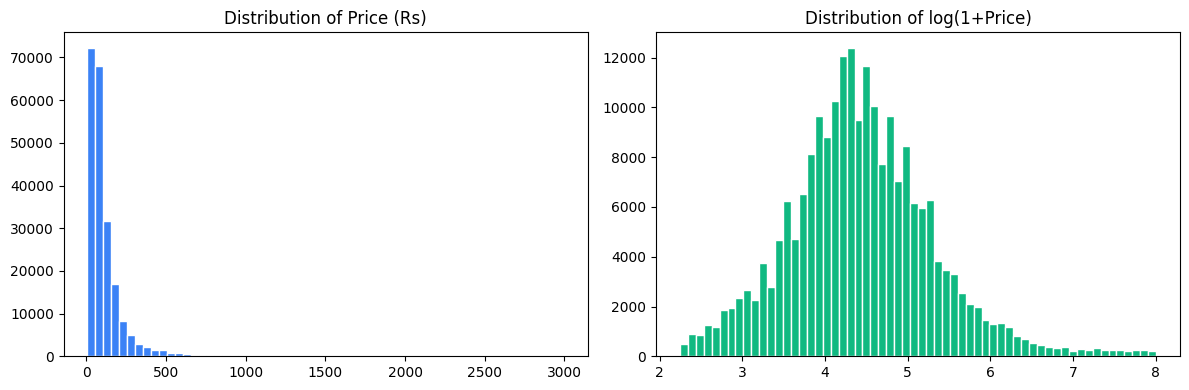

Skew of price: 6.76
Skew of log1p(price): 0.52


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(clean_df["price"], bins=60, color="#3b82f6", edgecolor="white")
axes[0].set_title("Distribution of Price (Rs)")
axes[1].hist(np.log1p(clean_df["price"]), bins=60, color="#10b981", edgecolor="white")
axes[1].set_title("Distribution of log(1+Price)")
plt.tight_layout()
plt.show()
print(f"Skew of price: {clean_df['price'].skew():.2f}")
print(f"Skew of log1p(price): {np.log1p(clean_df['price']).skew():.2f}")


### 6.2 Numeric feature distributions

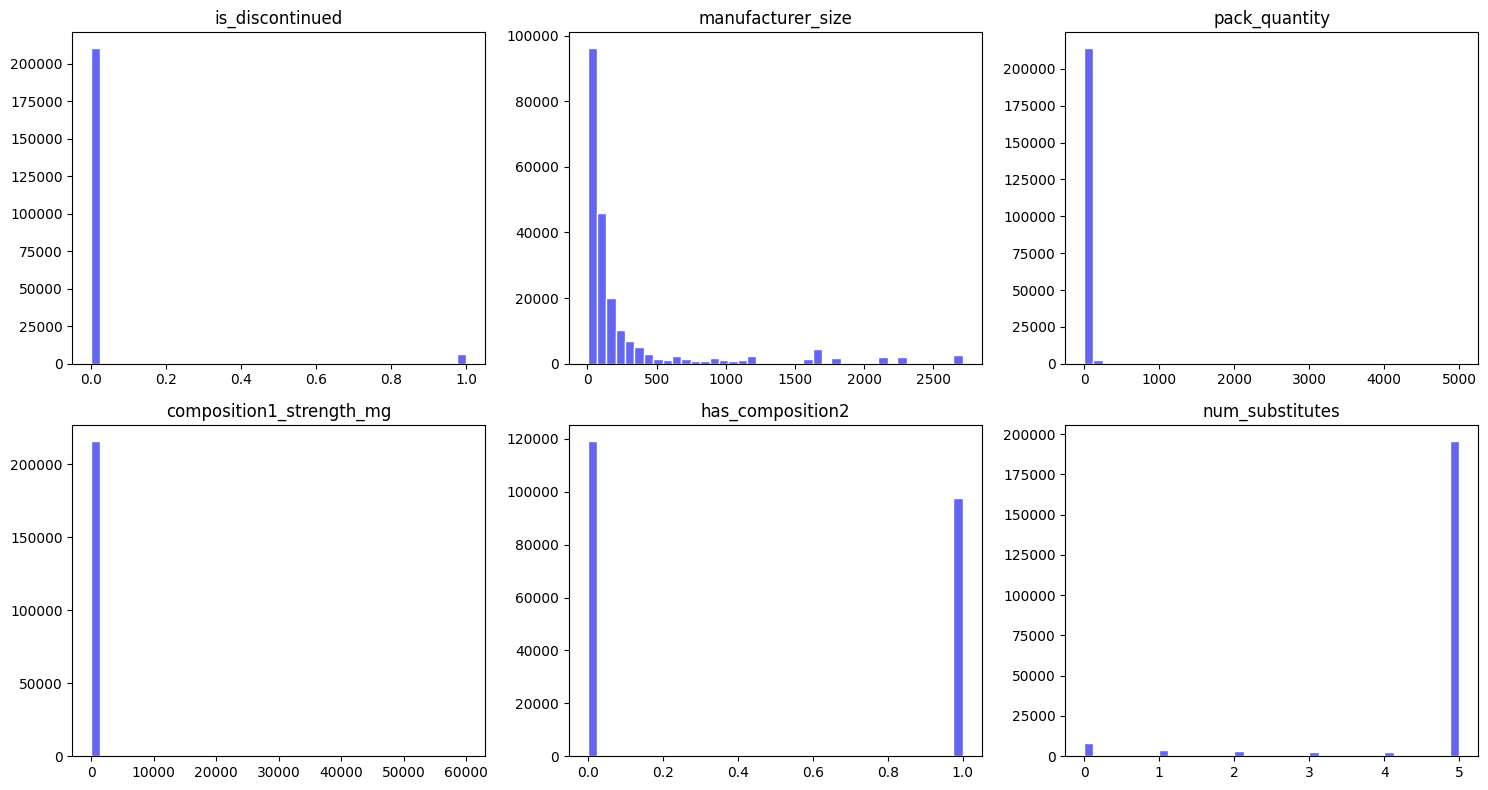

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), numeric_features[:6]):
    ax.hist(clean_df[col], bins=40, color="#6366f1", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 6.3 Correlation heatmap

Individual numeric correlations with log-price are modest — the strongest
is dosage strength (`composition1_strength_mg`, r ≈ 0.20), followed by
manufacturer size (r ≈ 0.10). `habit_forming` and `num_uses` are mildly
*negative*: habit-forming and multi-use drugs in this dataset skew toward
cheaper, high-volume generics. This tells us the numeric features alone
won't carry the model — the categorical features (therapeutic/chemical
class) matter more, confirmed next.

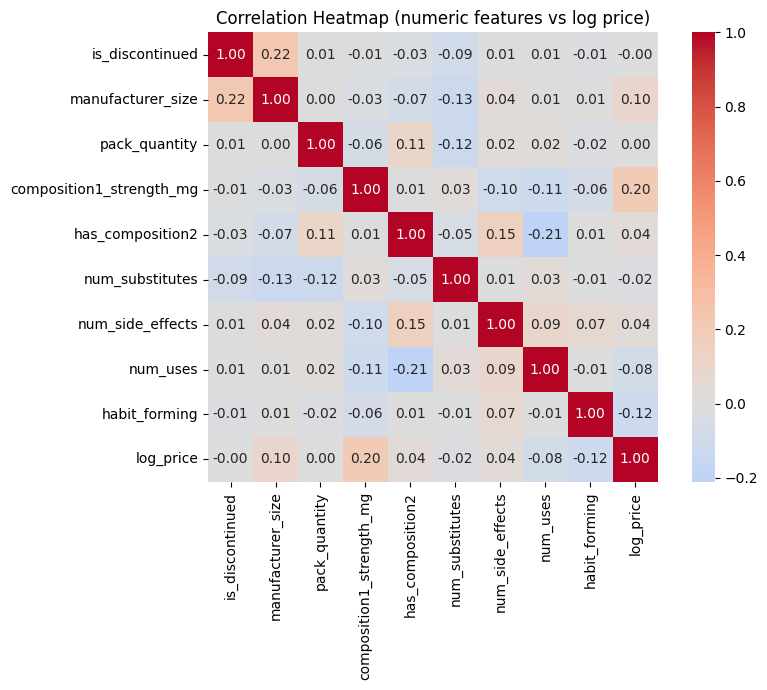

log_price                   1.000
composition1_strength_mg    0.198
manufacturer_size           0.097
has_composition2            0.039
num_side_effects            0.036
pack_quantity               0.003
is_discontinued            -0.003
num_substitutes            -0.020
num_uses                   -0.081
habit_forming              -0.116
Name: log_price, dtype: float64


In [8]:
corr_df = clean_df[numeric_features].copy()
corr_df["log_price"] = np.log1p(clean_df["price"])
corr = corr_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features vs log price)")
plt.tight_layout()
plt.show()
print(corr["log_price"].sort_values(ascending=False).round(3))


### 6.4 Price by therapeutic class

This is where most of the signal lives: median price ranges from **₹50**
(Otologicals) to **₹630** (Vaccines) — a 12x spread driven purely by
category. Anti-neoplastics (cancer drugs) and vaccines command the highest
prices, while everyday pain analgesics and respiratory medicines are the
cheapest — matching real-world intuition about drug economics.

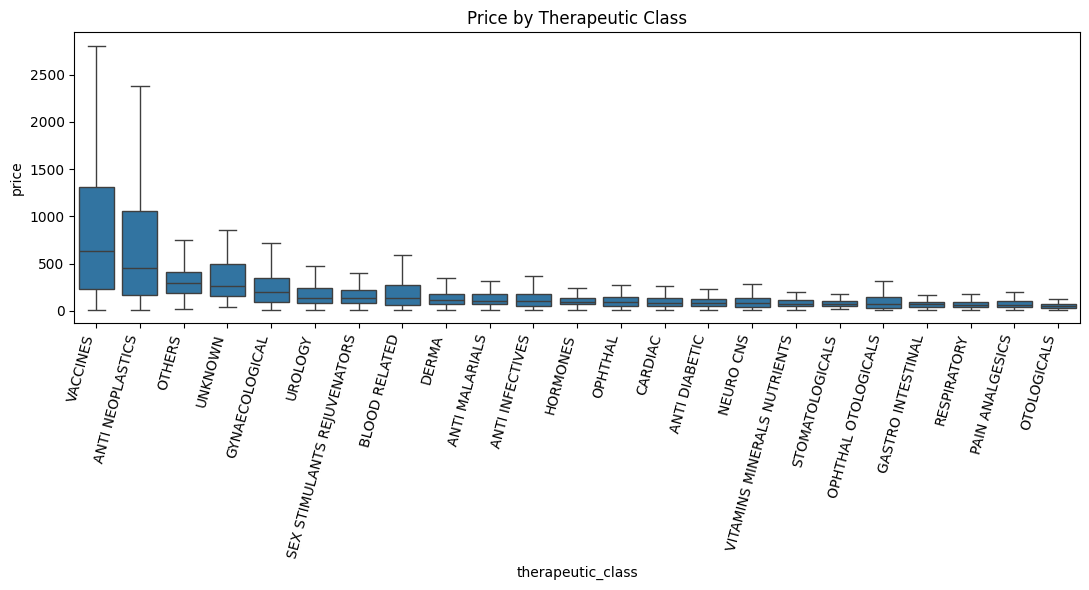

In [9]:
plt.figure(figsize=(11, 6))
order = clean_df.groupby("therapeutic_class")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=clean_df, x="therapeutic_class", y="price", order=order, showfliers=False)
plt.xticks(rotation=75, ha="right")
plt.title("Price by Therapeutic Class")
plt.tight_layout()
plt.show()


## 7. Encoding, standardization, train/test split

- Numeric features → `StandardScaler` (zero mean, unit variance).
- Categorical features → `OneHotEncoder` (unknown categories at inference
  time are safely ignored rather than raising an error — important once
  this model is served behind an API).
- 80/20 train/test split.

In [10]:
X = clean_df[numeric_features + categorical_features]
y = np.log1p(clean_df["price"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape, " Encoded width:", X_train_enc.shape[1])


Train: (173588, 13)  Test: (43398, 13)  Encoded width: 91


## 8. Model comparison: stochastic linear regression vs. 3 alternatives

Four regression approaches are trained and compared on the same
preprocessed features:

1. **SGDRegressor** — linear regression fit via **stochastic gradient
   descent** (`partial_fit` in a manual epoch loop, so we can track a
   train/test loss curve).
2. **LinearRegression** — the same linear model family, but solved with the
   closed-form OLS solution (no gradient descent) — isolates how much the
   *optimizer* itself matters vs. the model family.
3. **DecisionTreeRegressor** — a single non-linear tree.
4. **RandomForestRegressor** — an ensemble of trees.

In [11]:
def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

results = {}
preds = {}


### 8.1 SGD Linear Regression (stochastic gradient descent) + loss curve

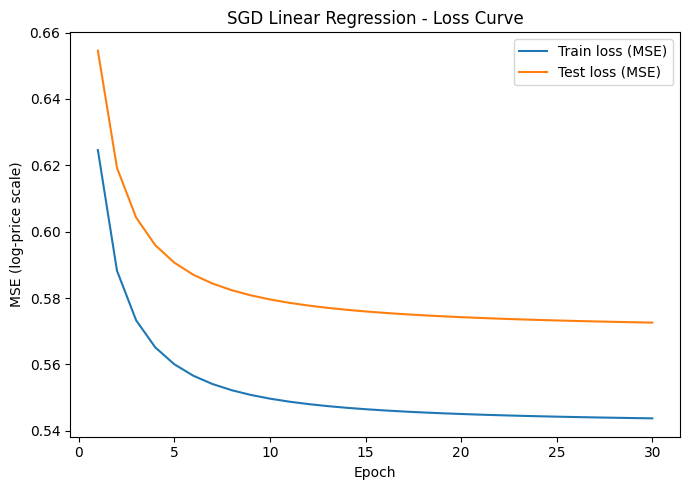

Final train MSE: 0.5437507180205458  Final test MSE: 0.572589787372413


In [12]:
sgd = SGDRegressor(loss="squared_error", penalty="l2", alpha=1e-4,
                    learning_rate="invscaling", eta0=0.01, random_state=RANDOM_STATE)

n_epochs = 30
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(X_train_enc, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_enc)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_enc)))

plt.figure(figsize=(7, 5))
plt.plot(range(1, n_epochs+1), train_losses, label="Train loss (MSE)")
plt.plot(range(1, n_epochs+1), test_losses, label="Test loss (MSE)")
plt.xlabel("Epoch"); plt.ylabel("MSE (log-price scale)")
plt.title("SGD Linear Regression - Loss Curve"); plt.legend()
plt.tight_layout()
plt.show()

sgd_train_pred = sgd.predict(X_train_enc)
sgd_test_pred = sgd.predict(X_test_enc)
results["SGD Linear Regression (stochastic)"] = {
    "train_rmse": rmse(y_train, sgd_train_pred), "test_rmse": rmse(y_test, sgd_test_pred),
    "test_mae": mean_absolute_error(y_test, sgd_test_pred), "test_r2": r2_score(y_test, sgd_test_pred),
}
preds["SGD Linear Regression (stochastic)"] = (sgd_train_pred, sgd_test_pred)
print("Final train MSE:", train_losses[-1], " Final test MSE:", test_losses[-1])


### 8.2 Linear Regression (closed-form OLS)

In [13]:
lr_pipe = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
lr_pipe.fit(X_train, y_train)
lr_train_pred, lr_test_pred = lr_pipe.predict(X_train), lr_pipe.predict(X_test)
results["Linear Regression (OLS)"] = {
    "train_rmse": rmse(y_train, lr_train_pred), "test_rmse": rmse(y_test, lr_test_pred),
    "test_mae": mean_absolute_error(y_test, lr_test_pred), "test_r2": r2_score(y_test, lr_test_pred),
}
preds["Linear Regression (OLS)"] = (lr_train_pred, lr_test_pred)
print("Test RMSE:", results["Linear Regression (OLS)"]["test_rmse"])


Test RMSE: 0.7516890607950407


### 8.3 Decision Tree Regressor

In [14]:
dt_pipe = Pipeline([("prep", preprocessor),
                     ("model", DecisionTreeRegressor(max_depth=10, min_samples_leaf=25, random_state=RANDOM_STATE))])
dt_pipe.fit(X_train, y_train)
dt_train_pred, dt_test_pred = dt_pipe.predict(X_train), dt_pipe.predict(X_test)
results["Decision Tree"] = {
    "train_rmse": rmse(y_train, dt_train_pred), "test_rmse": rmse(y_test, dt_test_pred),
    "test_mae": mean_absolute_error(y_test, dt_test_pred), "test_r2": r2_score(y_test, dt_test_pred),
}
preds["Decision Tree"] = (dt_train_pred, dt_test_pred)
print("Test RMSE:", results["Decision Tree"]["test_rmse"])


Test RMSE: 0.6821788595157897


### 8.4 Random Forest Regressor

In [15]:
rf_pipe = Pipeline([("prep", preprocessor),
                     ("model", RandomForestRegressor(n_estimators=60, max_depth=10,
                                                      min_samples_leaf=15, n_jobs=1,
                                                      random_state=RANDOM_STATE))])
rf_pipe.fit(X_train, y_train)
rf_train_pred, rf_test_pred = rf_pipe.predict(X_train), rf_pipe.predict(X_test)
results["Random Forest"] = {
    "train_rmse": rmse(y_train, rf_train_pred), "test_rmse": rmse(y_test, rf_test_pred),
    "test_mae": mean_absolute_error(y_test, rf_test_pred), "test_r2": r2_score(y_test, rf_test_pred),
}
preds["Random Forest"] = (rf_train_pred, rf_test_pred)
print("Test RMSE:", results["Random Forest"]["test_rmse"])


Test RMSE: 0.6575161766140826


### 8.5 Comparison table

**Random Forest wins** on every metric. Interpretation: price is driven by
non-linear interactions between category (therapeutic/chemical class) and
numeric attributes (e.g. dosage strength matters *differently* within
"Anti Neoplastics" than within "Pain Analgesics") — patterns tree ensembles
capture naturally but a linear model cannot, regardless of whether it's
fit with gradient descent or a closed-form solution (the two linear
variants land within ~0.005 RMSE of each other, confirming the *optimizer*
isn't the bottleneck — the *linear model family* is).

In [16]:
results_df = pd.DataFrame(results).T.sort_values("test_rmse")
print(results_df)


                                    train_rmse  test_rmse  test_mae   test_r2
Random Forest                         0.645135   0.657516  0.471795  0.451308
Decision Tree                         0.669783   0.682179  0.484880  0.409375
Linear Regression (OLS)               0.735403   0.751689  0.550701  0.282880
SGD Linear Regression (stochastic)    0.737395   0.756697  0.552192  0.273293


## 9. Best model: fit visualization

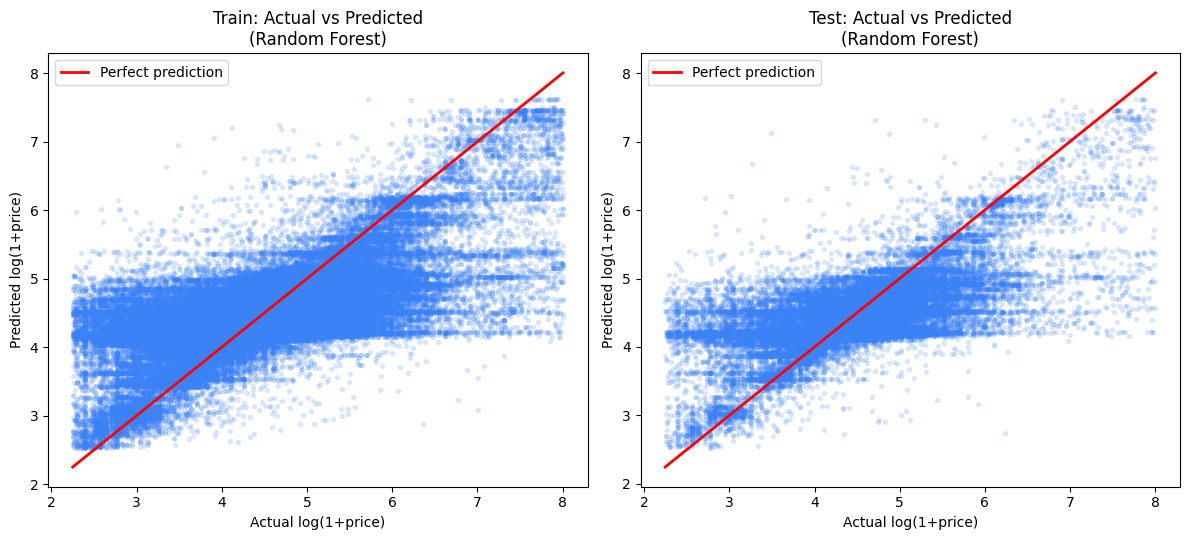

In [17]:
best_name = results_df.index[0]
best_train_pred, best_test_pred = preds[best_name]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, y_true, y_pred, title in [
    (axes[0], y_train, best_train_pred, "Train: Actual vs Predicted"),
    (axes[1], y_test, best_test_pred, "Test: Actual vs Predicted"),
]:
    ax.scatter(y_true, y_pred, alpha=0.15, s=8, color="#3b82f6")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="red", linewidth=2, label="Perfect prediction")
    ax.set_xlabel("Actual log(1+price)"); ax.set_ylabel("Predicted log(1+price)")
    ax.set_title(f"{title}\n({best_name})"); ax.legend()
plt.tight_layout()
plt.show()


### Before / after: single-feature illustration

The scatter above uses all 13 features, so there's no single "line" to
draw. For an illustrative before/after of what a fitted linear regression
line looks like, here is a **simple single-feature regression** of
log-price on dosage strength alone (the strongest individual numeric
correlate):

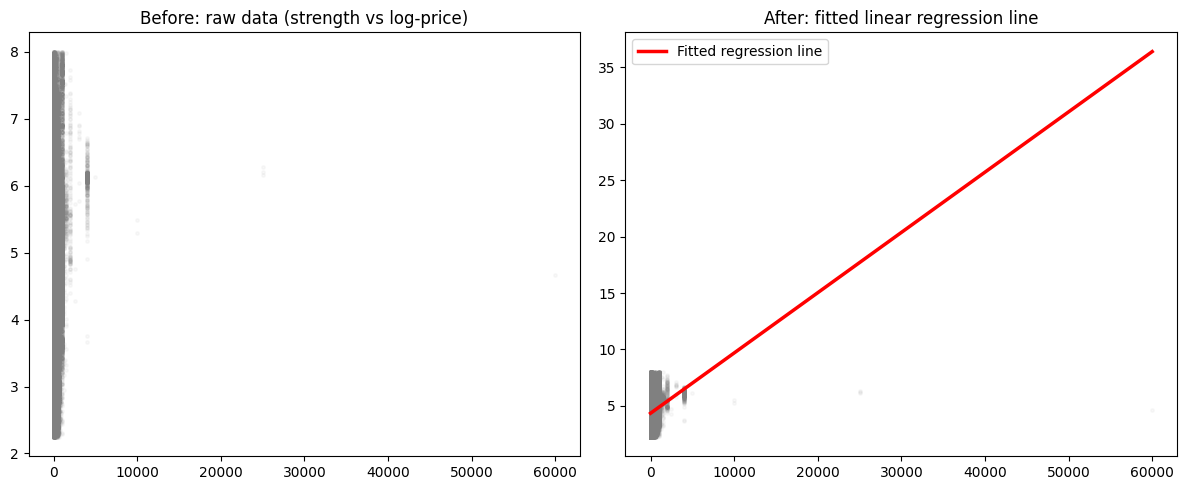

In [18]:
simple_lr = LinearRegression()
x_feat = clean_df[["composition1_strength_mg"]].values
y_target = np.log1p(clean_df["price"]).values
simple_lr.fit(x_feat, y_target)
x_line = np.linspace(x_feat.min(), x_feat.max(), 100).reshape(-1, 1)
y_line = simple_lr.predict(x_line)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(x_feat, y_target, alpha=0.05, s=6, color="gray")
axes[0].set_title("Before: raw data (strength vs log-price)")
axes[1].scatter(x_feat, y_target, alpha=0.05, s=6, color="gray")
axes[1].plot(x_line, y_line, color="red", linewidth=2.5, label="Fitted regression line")
axes[1].set_title("After: fitted linear regression line")
axes[1].legend()
plt.tight_layout()
plt.show()


## 10. Save the best-performing model

In [19]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(rf_pipe, "models/best_model.pkl")
with open("models/best_model_name.txt", "w") as f:
    f.write(best_name)
print(f"Saved best model: {best_name} -> models/best_model.pkl")


Saved best model: Random Forest -> models/best_model.pkl


## 11. Prediction on a single held-out data point

This is the function Task 2's API will wrap. the function is also in prediction.py


In [20]:
def predict_price(pipeline, row_dict):
    """row_dict must contain all numeric_features + categorical_features keys."""
    row_df = pd.DataFrame([row_dict])
    log_price_pred = pipeline.predict(row_df)[0]
    return float(np.expm1(log_price_pred))

# Take one row from the held-out test set
sample_row = X_test.iloc[0].to_dict()
actual_price = float(np.expm1(y_test.iloc[0]))
predicted_price = predict_price(rf_pipe, sample_row)

print("Sample input:", sample_row)
print(f"Actual price:    Rs {actual_price:.2f}")
print(f"Predicted price: Rs {predicted_price:.2f}")


Sample input: {'is_discontinued': 0, 'manufacturer_size': 36, 'pack_quantity': 10.0, 'composition1_strength_mg': 100.0, 'has_composition2': 1, 'num_substitutes': 5, 'num_side_effects': 7, 'num_uses': 1, 'habit_forming': 0, 'pack_container': 'strip', 'pack_form': 'tablets', 'therapeutic_class': 'PAIN ANALGESICS', 'chemical_class': 'OTHER'}
Actual price:    Rs 95.00
Predicted price: Rs 70.67
